# Notebook 09 — Gradient Boosting (XGBoost + LightGBM)

**Proyecto:** PFM MUCSI Deusto — Predicción de consumo eléctrico doméstico
**Fase:** 2 — Modelado y comparativa (segundo bloque de modelos clásicos)
**Fecha:** 2026-05-12

## Objetivo

Entrenar y comparar dos modelos de **gradient boosting** (XGBoost y LightGBM) bajo el mismo
protocolo experimental que el Random Forest del Nb08. Decidir cuál de los tres pasa a la
comparativa final con redes neuronales.

## Protocolo (idéntico al Nb08)

- Granularidad: **15 min** (resampling con media).
- Features: **22** (5 temporales + 1 binaria + 8 cíclicas + 4 lags + 4 rolling), recalculadas sobre la frecuencia objetivo.
- Split: **80/20 cronológico** por hogar.
- Horizontes: **15, 60, 1440 min**.
- Estrategia: **solo modelo global** con `id_hogar` como feature ordinal (decisión registrada tras Nb08 — la transferabilidad supera a la personalización).
- Métricas: RMSE, MAE, MAPE (filtrado >50 W), R².

## Hiperparámetros

Valores razonables, sin tuning agresivo (eso se reserva para el modelo finalista en Nb10):

| Modelo | n_estimators | max_depth | learning_rate | regularización |
|--------|-------------:|----------:|--------------:|----------------|
| XGBoost | 300 | 8 | 0,05 | min_child_weight=10, subsample=0,9 |
| LightGBM | 300 | −1 (libre) | 0,05 | num_leaves=63, min_child_samples=20 |


## 1. Imports y configuración

In [1]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEMILLA = 42
np.random.seed(SEMILLA)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 13

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DIR_PROCESSED = RAIZ / "datos" / "processed"
DIR_METRICAS = RAIZ / "resultados" / "metricas"
DIR_FIGURAS = RAIZ / "resultados" / "figuras"
DIR_METRICAS.mkdir(parents=True, exist_ok=True)
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)

print(f"XGBoost {xgb.__version__} | LightGBM {lgb.__version__} | pandas {pd.__version__}")
print(f"Ruta raíz: {RAIZ}")


XGBoost 3.2.0 | LightGBM 4.6.0 | pandas 2.2.3
Ruta raíz: C:\Users\super\Desktop\PFM_MUCSI_Deusto


## 2. Configuración del experimento

In [2]:
HOGARES_TRAIN = [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 16, 17, 18, 19, 20, 21]
HOGARES_VALIDACION_EXTERNA = [2, 13]

FRECUENCIA = "15min"
PASOS_POR_HORA = 4
PASOS_POR_DIA = 24 * PASOS_POR_HORA
PASOS_POR_SEMANA = 7 * PASOS_POR_DIA

HORIZONTES_MIN = [15, 60, 1440]
HORIZONTES_PASOS = [h // 15 for h in HORIZONTES_MIN]

FRACCION_TEST = 0.20
UMBRAL_MAPE_W = 50.0

XGB_PARAMS = dict(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    min_child_weight=10,
    subsample=0.9,
    colsample_bytree=0.9,
    tree_method="hist",
    objective="reg:squarederror",
    random_state=SEMILLA,
    n_jobs=-1,
    verbosity=0,
)

LGBM_PARAMS = dict(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEMILLA,
    n_jobs=-1,
    verbose=-1,
)

print(f"Horizontes (min → pasos): {dict(zip(HORIZONTES_MIN, HORIZONTES_PASOS))}")


Horizontes (min → pasos): {15: 1, 60: 4, 1440: 96}


## 3. Funciones auxiliares

Las mismas funciones del Nb08 — replicadas aquí para mantener el notebook autocontenido.

In [3]:
def cargar_aggregate_resampleado(id_hogar: int, frecuencia: str = FRECUENCIA) -> pd.Series:
    '''Devuelve la serie Aggregate con índice temporal a la frecuencia indicada.'''
    ruta_features = DIR_PROCESSED / f"house{id_hogar}_features.csv"
    ruta_limpio = DIR_PROCESSED / f"house{id_hogar}_1min_limpio.csv"
    ruta = ruta_features if ruta_features.exists() else ruta_limpio
    if not ruta.exists():
        raise FileNotFoundError(f"No se encuentra el fichero para House{id_hogar}")
    cabecera = pd.read_csv(ruta, nrows=0).columns
    col_tiempo = "timestamp" if "timestamp" in cabecera else "Time"
    df = pd.read_csv(ruta, usecols=[col_tiempo, "Aggregate"], parse_dates=[col_tiempo])
    df = df.rename(columns={col_tiempo: "fecha"}).set_index("fecha").sort_index()
    return df["Aggregate"].resample(frecuencia).mean()


def construir_features(serie: pd.Series) -> pd.DataFrame:
    '''Construye 22 features sobre la frecuencia de la serie.'''
    df = pd.DataFrame({"Aggregate": serie})
    idx = df.index
    df["hora"] = idx.hour
    df["minuto"] = idx.minute
    df["dia_semana"] = idx.dayofweek
    df["dia_mes"] = idx.day
    df["mes"] = idx.month
    df["es_finde"] = (idx.dayofweek >= 5).astype(int)
    df["hora_sin"] = np.sin(2 * np.pi * df["hora"] / 24)
    df["hora_cos"] = np.cos(2 * np.pi * df["hora"] / 24)
    df["dia_semana_sin"] = np.sin(2 * np.pi * df["dia_semana"] / 7)
    df["dia_semana_cos"] = np.cos(2 * np.pi * df["dia_semana"] / 7)
    df["mes_sin"] = np.sin(2 * np.pi * df["mes"] / 12)
    df["mes_cos"] = np.cos(2 * np.pi * df["mes"] / 12)
    df["dia_anyo"] = idx.dayofyear
    df["dia_anyo_sin"] = np.sin(2 * np.pi * df["dia_anyo"] / 365)
    df["lag_1"] = df["Aggregate"].shift(1)
    df["lag_1h"] = df["Aggregate"].shift(PASOS_POR_HORA)
    df["lag_1d"] = df["Aggregate"].shift(PASOS_POR_DIA)
    df["lag_7d"] = df["Aggregate"].shift(PASOS_POR_SEMANA)
    df["media_movil_1h"] = df["Aggregate"].shift(1).rolling(PASOS_POR_HORA).mean()
    df["media_movil_6h"] = df["Aggregate"].shift(1).rolling(6 * PASOS_POR_HORA).mean()
    df["media_movil_1d"] = df["Aggregate"].shift(1).rolling(PASOS_POR_DIA).mean()
    df["std_movil_1d"] = df["Aggregate"].shift(1).rolling(PASOS_POR_DIA).std()
    return df


def preparar_xy_horizonte(df_features: pd.DataFrame, pasos_horizonte: int):
    df = df_features.copy()
    df["target"] = df["Aggregate"].shift(-pasos_horizonte)
    df = df.dropna(subset=["target"]).dropna()
    columnas = [c for c in df.columns if c not in ("Aggregate", "target")]
    return df[columnas], df["target"], columnas


def evaluar(y_true, y_pred, umbral_mape: float = UMBRAL_MAPE_W) -> dict:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    m = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_t, y_p = y_true[m], y_pred[m]
    if len(y_t) == 0:
        return dict(rmse=np.nan, mae=np.nan, mape=np.nan, r2=np.nan, n=0)
    rmse = float(np.sqrt(mean_squared_error(y_t, y_p)))
    mae = float(mean_absolute_error(y_t, y_p))
    r2 = float(r2_score(y_t, y_p))
    mm = y_t > umbral_mape
    mape = float(np.mean(np.abs((y_t[mm] - y_p[mm]) / y_t[mm])) * 100) if mm.sum() else np.nan
    return dict(rmse=rmse, mae=mae, mape=mape, r2=r2, n=int(len(y_t)))


def preparar_dataset_global(features_dict, hogares_train, h_pasos):
    '''Concatena los hogares train con id_hogar y devuelve frames + splits del test.'''
    frames_tr, splits_te = [], {}
    cols_finales = None
    for id_h in hogares_train:
        df_feat = features_dict[id_h].copy()
        df_feat["id_hogar"] = id_h
        X, y, cols = preparar_xy_horizonte(df_feat, h_pasos)
        cols_finales = cols
        corte = int(len(X) * (1 - FRACCION_TEST))
        frames_tr.append(pd.concat([X.iloc[:corte], y.iloc[:corte].rename("target")], axis=1))
        splits_te[id_h] = pd.concat([X.iloc[corte:], y.iloc[corte:].rename("target")], axis=1)
    return pd.concat(frames_tr, ignore_index=False), splits_te, cols_finales


print("Funciones cargadas.")


Funciones cargadas.


## 4. Carga y construcción de features (20 hogares)

In [4]:
t0 = time.time()
hogares = HOGARES_TRAIN + HOGARES_VALIDACION_EXTERNA
features_por_hogar = {}
for id_h in hogares:
    serie = cargar_aggregate_resampleado(id_h)
    features_por_hogar[id_h] = construir_features(serie)
print(f"Carga + features: {time.time() - t0:.1f} s | {len(features_por_hogar)} hogares")


Carga + features: 37.8 s | 20 hogares


## 5. Bloque A — XGBoost global

In [5]:
resultados_xgb = []
importancia_xgb = {}

for h_min, h_pasos in zip(HORIZONTES_MIN, HORIZONTES_PASOS):
    print(f"\n=== XGBoost — horizonte {h_min} min ===")
    train_df, splits_te, cols_global = preparar_dataset_global(features_por_hogar, HOGARES_TRAIN, h_pasos)
    X_tr = train_df[cols_global]
    y_tr = train_df["target"]
    print(f"Train: {len(X_tr):>7} filas × {X_tr.shape[1]} features")

    t_ini = time.time()
    modelo = xgb.XGBRegressor(**XGB_PARAMS)
    modelo.fit(X_tr, y_tr)
    print(f"Entrenamiento: {time.time() - t_ini:.1f} s")
    importancia_xgb[h_min] = dict(zip(X_tr.columns, modelo.feature_importances_))

    for id_h in hogares:
        df_feat = features_por_hogar[id_h].copy()
        df_feat["id_hogar"] = id_h
        X, y, _ = preparar_xy_horizonte(df_feat, h_pasos)
        if len(X) < 1000:
            continue
        corte = int(len(X) * (1 - FRACCION_TEST))
        X_te = X.iloc[corte:][cols_global]
        y_te = y.iloc[corte:]
        y_pred = modelo.predict(X_te)
        rol = "train" if id_h in HOGARES_TRAIN else "validacion_externa"
        resultados_xgb.append(dict(
            hogar=id_h, rol=rol, horizonte_min=h_min, estrategia="xgboost",
            **evaluar(y_te.to_numpy(), y_pred),
        ))

tabla_xgb = pd.DataFrame(resultados_xgb)
print(f"\nBloque XGBoost: {len(tabla_xgb)} filas")



=== XGBoost — horizonte 15 min ===


Train:  589293 filas × 23 features


Entrenamiento: 4.1 s



=== XGBoost — horizonte 60 min ===


Train:  588680 filas × 23 features


Entrenamiento: 4.1 s



=== XGBoost — horizonte 1440 min ===


Train:  577716 filas × 23 features


Entrenamiento: 4.1 s



Bloque XGBoost: 60 filas


## 6. Bloque B — LightGBM global

In [6]:
resultados_lgbm = []
importancia_lgbm = {}

for h_min, h_pasos in zip(HORIZONTES_MIN, HORIZONTES_PASOS):
    print(f"\n=== LightGBM — horizonte {h_min} min ===")
    train_df, splits_te, cols_global = preparar_dataset_global(features_por_hogar, HOGARES_TRAIN, h_pasos)
    X_tr = train_df[cols_global]
    y_tr = train_df["target"]
    print(f"Train: {len(X_tr):>7} filas × {X_tr.shape[1]} features")

    t_ini = time.time()
    modelo = lgb.LGBMRegressor(**LGBM_PARAMS)
    modelo.fit(X_tr, y_tr)
    print(f"Entrenamiento: {time.time() - t_ini:.1f} s")
    # LightGBM devuelve la importancia en escala "split" por defecto
    importancia_lgbm[h_min] = dict(zip(X_tr.columns,
                                       modelo.booster_.feature_importance(importance_type="gain")))

    for id_h in hogares:
        df_feat = features_por_hogar[id_h].copy()
        df_feat["id_hogar"] = id_h
        X, y, _ = preparar_xy_horizonte(df_feat, h_pasos)
        if len(X) < 1000:
            continue
        corte = int(len(X) * (1 - FRACCION_TEST))
        X_te = X.iloc[corte:][cols_global]
        y_te = y.iloc[corte:]
        y_pred = modelo.predict(X_te)
        rol = "train" if id_h in HOGARES_TRAIN else "validacion_externa"
        resultados_lgbm.append(dict(
            hogar=id_h, rol=rol, horizonte_min=h_min, estrategia="lightgbm",
            **evaluar(y_te.to_numpy(), y_pred),
        ))

tabla_lgbm = pd.DataFrame(resultados_lgbm)
print(f"\nBloque LightGBM: {len(tabla_lgbm)} filas")



=== LightGBM — horizonte 15 min ===


Train:  589293 filas × 23 features


Entrenamiento: 1.9 s



=== LightGBM — horizonte 60 min ===


Train:  588680 filas × 23 features


Entrenamiento: 2.0 s



=== LightGBM — horizonte 1440 min ===


Train:  577716 filas × 23 features


Entrenamiento: 2.0 s



Bloque LightGBM: 60 filas


## 7. Comparativa unificada — baselines + RF + XGBoost + LightGBM

In [7]:
# Cargar tabla completa del Nb08 (que ya incluye baselines + RF global y por hogar)
tabla_previa = pd.read_csv(DIR_METRICAS / "08_random_forest.csv")

# Filtrar solo modelos que vamos a comparar (RF global + baselines), no rf_por_hogar
tabla_previa = tabla_previa[tabla_previa["estrategia"].isin(
    ["baseline_persistencia", "baseline_media_hora_dia", "rf_global"]
)]

cols_comunes = ["hogar", "rol", "horizonte_min", "estrategia", "rmse", "mae", "mape", "r2", "n"]
tabla_completa = pd.concat([
    tabla_previa[cols_comunes],
    tabla_xgb[cols_comunes],
    tabla_lgbm[cols_comunes],
], ignore_index=True)

print("Estrategias:", sorted(tabla_completa["estrategia"].unique()))
print(f"Total filas: {len(tabla_completa)}")
tabla_completa.head()


Estrategias: ['baseline_media_hora_dia', 'baseline_persistencia', 'lightgbm', 'rf_global', 'xgboost']
Total filas: 300


,hogar,rol,horizonte_min,estrategia,rmse,mae,mape,r2,n
0,1,train,15,baseline_persistencia,845.248374,242.212332,54.911339,-0.591859,143889
1,1,train,15,baseline_media_hora_dia,676.977065,356.974717,118.666633,-0.021982,144085
2,1,train,60,baseline_persistencia,889.302482,291.799071,72.881111,-0.776566,143373
3,1,train,60,baseline_media_hora_dia,677.029970,356.958269,118.681983,-0.022027,144040
4,1,train,1440,baseline_persistencia,870.871659,279.359905,74.295047,-0.763563,132314


In [8]:
resumen = (
    tabla_completa.groupby(["rol", "horizonte_min", "estrategia"])
    [["rmse", "mae", "mape", "r2"]]
    .mean().round(2)
)
print("=== Comparativa global (media por rol/horizonte/estrategia) ===")
print(resumen.to_string())


=== Comparativa global (media por rol/horizonte/estrategia) ===
                                                             rmse     mae    mape    r2
rol                horizonte_min estrategia                                            
train              15            baseline_media_hora_dia   604.15  341.58   89.01  0.04
                                 baseline_persistencia     669.17  255.63   53.72 -0.23
                                 lightgbm                  419.86  221.44   49.52  0.33
                                 rf_global                 424.66  226.08   50.74  0.32
                                 xgboost                   418.74  221.02   48.95  0.34
                   60            baseline_media_hora_dia   604.17  341.60   89.02  0.04
                                 baseline_persistencia     763.00  322.62   72.94 -0.57
                                 lightgbm                  448.85  250.62   59.05  0.25
                                 rf_global              

## 8. Visualizaciones

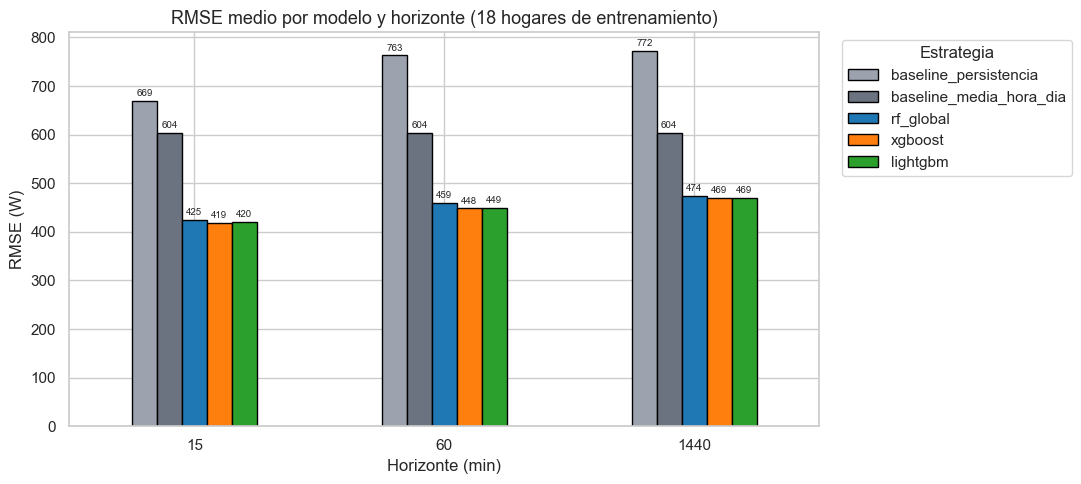

In [9]:
# Figura 09a — RMSE medio por modelo y horizonte (train)
fig, ax = plt.subplots(figsize=(11, 5))
orden = ["baseline_persistencia", "baseline_media_hora_dia", "rf_global", "xgboost", "lightgbm"]
pivot = resumen.loc["train", "rmse"].unstack("estrategia")[orden]
pivot.plot(kind="bar", ax=ax, edgecolor="black",
           color=["#9ca3af", "#6b7280", "#1f77b4", "#ff7f0e", "#2ca02c"])
ax.set_title("RMSE medio por modelo y horizonte (18 hogares de entrenamiento)")
ax.set_xlabel("Horizonte (min)")
ax.set_ylabel("RMSE (W)")
ax.legend(title="Estrategia", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_xticklabels(pivot.index, rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", fontsize=7, padding=2)
plt.tight_layout()
plt.savefig(DIR_FIGURAS / "09_rmse_comparativa_modelos.png", dpi=120, bbox_inches="tight")
plt.show()


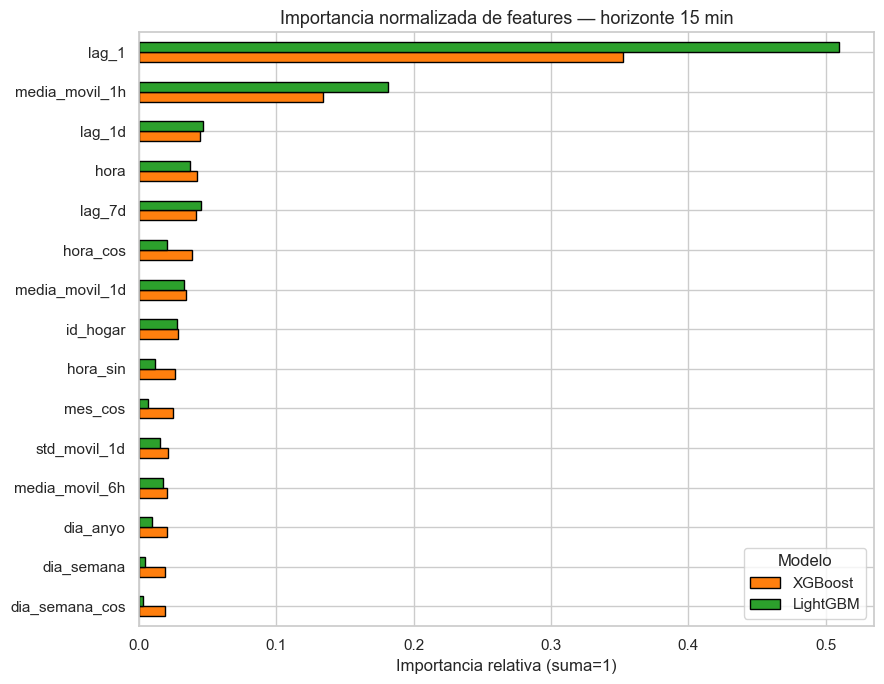

Top 5 XGBoost:
lag_1             0.352
media_movil_1h    0.134
lag_1d            0.044
hora              0.042
lag_7d            0.042

Top 5 LightGBM:
lag_1             0.510
media_movil_1h    0.181
lag_1d            0.047
lag_7d            0.045
hora              0.037


In [10]:
# Figura 09b — Importancia de features XGBoost vs LightGBM (horizonte 15 min)
imp_xgb = pd.Series(importancia_xgb[15]).sort_values(ascending=False)
imp_lgbm = pd.Series(importancia_lgbm[15]).sort_values(ascending=False)
# Normalizar a 0-1 para comparar
imp_xgb_n = imp_xgb / imp_xgb.sum()
imp_lgbm_n = imp_lgbm / imp_lgbm.sum()

df_imp = pd.concat({"XGBoost": imp_xgb_n, "LightGBM": imp_lgbm_n}, axis=1).fillna(0)
df_imp = df_imp.sort_values("XGBoost", ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 7))
df_imp.plot(kind="barh", ax=ax, edgecolor="black", color=["#ff7f0e", "#2ca02c"])
ax.set_title("Importancia normalizada de features — horizonte 15 min")
ax.set_xlabel("Importancia relativa (suma=1)")
ax.legend(title="Modelo")
plt.tight_layout()
plt.savefig(DIR_FIGURAS / "09_importancia_features_h15.png", dpi=120, bbox_inches="tight")
plt.show()

print("Top 5 XGBoost:")
print(imp_xgb_n.head(5).round(3).to_string())
print("\nTop 5 LightGBM:")
print(imp_lgbm_n.head(5).round(3).to_string())


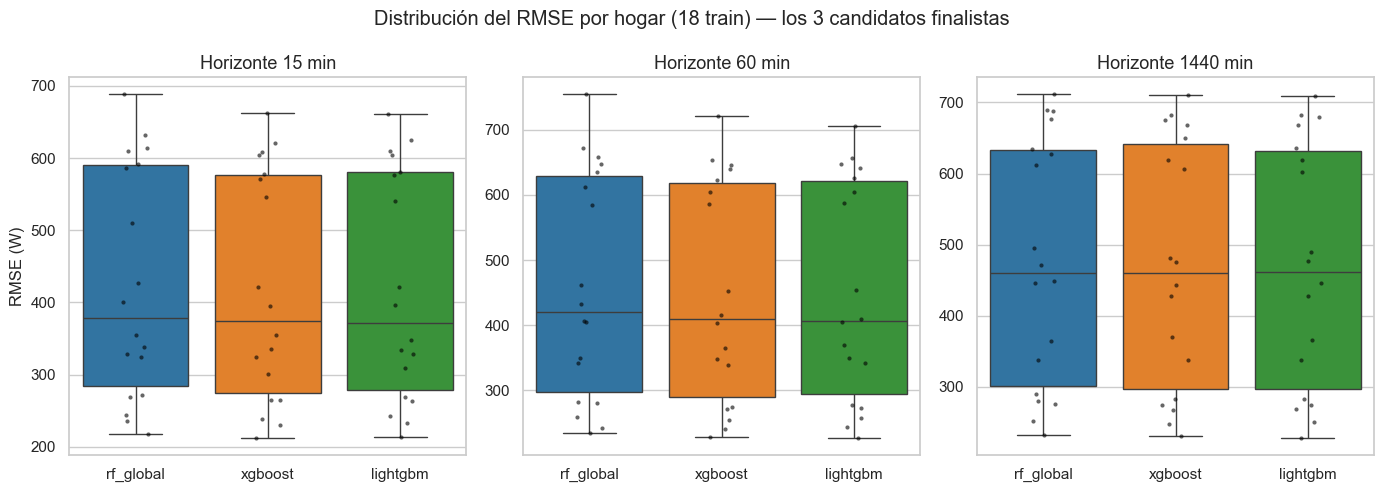

In [11]:
# Figura 09c — Boxplot RMSE por hogar entre los 3 candidatos
df_modelo = tabla_completa[tabla_completa["estrategia"].isin(["rf_global", "xgboost", "lightgbm"])]
df_modelo = df_modelo[df_modelo["rol"] == "train"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
for ax, h in zip(axes, HORIZONTES_MIN):
    sub = df_modelo[df_modelo["horizonte_min"] == h]
    sns.boxplot(data=sub, x="estrategia", y="rmse", ax=ax,
                order=["rf_global", "xgboost", "lightgbm"],
                palette=["#1f77b4", "#ff7f0e", "#2ca02c"])
    sns.stripplot(data=sub, x="estrategia", y="rmse", ax=ax,
                  order=["rf_global", "xgboost", "lightgbm"],
                  color="black", size=3, alpha=0.6)
    ax.set_title(f"Horizonte {h} min")
    ax.set_xlabel("")
    ax.set_ylabel("RMSE (W)" if h == HORIZONTES_MIN[0] else "")
plt.suptitle("Distribución del RMSE por hogar (18 train) — los 3 candidatos finalistas")
plt.tight_layout()
plt.savefig(DIR_FIGURAS / "09_boxplot_rmse_finalistas.png", dpi=120, bbox_inches="tight")
plt.show()


## 9. Exportación de resultados

In [12]:
ruta_csv = DIR_METRICAS / "09_boosting.csv"
tabla_completa.to_csv(ruta_csv, index=False)
print(f"Tabla completa: {ruta_csv} ({len(tabla_completa)} filas)")

ruta_resumen = DIR_METRICAS / "09_boosting_resumen.csv"
resumen.to_csv(ruta_resumen)
print(f"Resumen: {ruta_resumen}")

# Importancias de features
df_imp_xgb = pd.DataFrame(importancia_xgb).round(4)
df_imp_xgb.index.name = "feature"
df_imp_xgb.to_csv(DIR_METRICAS / "09_importancia_features_xgb.csv")

df_imp_lgbm = pd.DataFrame(importancia_lgbm).round(4)
df_imp_lgbm.index.name = "feature"
df_imp_lgbm.to_csv(DIR_METRICAS / "09_importancia_features_lgbm.csv")
print("Importancias XGBoost y LightGBM exportadas.")


Tabla completa: C:\Users\super\Desktop\PFM_MUCSI_Deusto\resultados\metricas\09_boosting.csv (300 filas)
Resumen: C:\Users\super\Desktop\PFM_MUCSI_Deusto\resultados\metricas\09_boosting_resumen.csv
Importancias XGBoost y LightGBM exportadas.


## 10. Conclusiones y siguientes pasos

Los hallazgos detallados se recogen en `resultados/09_hallazgos_boosting.md` una vez ejecutado el notebook.
Esquema a completar con los valores reales:

- **¿Cuál de los tres modelos clásicos gana en cada horizonte?** (RF global / XGBoost / LightGBM).
- **¿La diferencia es estadísticamente significativa?** Inspeccionar los boxplot por hogar.
- **¿XGBoost o LightGBM es más rápido?** El tiempo de entrenamiento por horizonte queda registrado en el log.
- **¿Las importancias coinciden con las del RF?** (lag_1 dominante en corto plazo, lag_1d/7d en largo plazo).

### Siguiente paso — Notebook 10

Tuning de hiperparámetros del modelo ganador (RandomizedSearchCV + validación temporal). Después de Nb10
el modelo finalista clásico queda fijado y se compara contra las redes neuronales (LSTM / Transformer)
en Nb11 y Nb12.